# Tutorial 11: Working with BruteForce Results

This tutorial covers loading, interpreting, and post-processing the HDF5 output
files produced by `brutus.analysis.BruteForce`. After a fit completes, the
results file contains posterior samples, best-fit statistics, and covariance
matrices for every object. Understanding how to work with these arrays is
essential for extracting science from brutus.

## Topics Covered

1. **Loading results** -- HDF5 structure, keys, shapes, and dtypes
2. **Understanding output arrays** -- what each dataset represents
3. **Computing posterior summaries** -- medians, credible intervals, distances
4. **Sampling from posteriors** -- drawing (s, A_V, R_V) realizations
5. **Photometric conversions** -- flux vs magnitude representations
6. **Visualization** -- `dist_vs_red` and `cornerplot`
7. **Quality assessment** -- chi2/dof diagnostics and outlier flagging

## Prerequisites

This tutorial uses the pre-computed BruteForce results file
`Orion_l209.1_b-19.9_mist.h5`. If this file is not available, cells that
depend on it will print a skip message and continue.

In [1]:
# Setup: imports and plot style
import warnings

import numpy as np
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")

# Tutorial utilities
from tutorial_utils import (
    setup_tutorial,
    save_figure,
    print_section,
    find_brutus_data_file,
    load_example_results,
    assert_array_properties,
)

# Run the standardized tutorial bootstrap
info = setup_tutorial(11, title="Tutorial 11: Working with BruteForce Results")

# Matplotlib defaults for this notebook
plt.rcParams["figure.figsize"] = (10, 6)


Tutorial 11: Working with BruteForce Results

Checking data requirements for Tutorial 11
  Found: Orion_l209.1_b-19.9_mist.h5

  All required files available


---
## Section 1: Loading Results

BruteForce writes its output to an HDF5 file containing several datasets.
The convenience function `load_example_results()` from `tutorial_utils`
loads all top-level datasets into a dictionary. We also demonstrate
opening the file directly with `h5py` to inspect its raw structure.

In [2]:
# ---------------------------------------------------------------
# Load pre-computed BruteForce results
# ---------------------------------------------------------------
DATA_AVAILABLE = False
results = None

try:
    results = load_example_results("Orion_l209.1_b-19.9_mist.h5")
    DATA_AVAILABLE = True
    print("Loaded BruteForce results.")
    print(f"  File: {results['filename']}")
except FileNotFoundError as exc:
    print("Results file not found -- sections that need it will be skipped.")
    print(f"  ({exc})")

Loaded BruteForce results.
  File: /home/user/brutus/tutorials/Orion_l209.1_b-19.9_mist.h5


In [3]:
# ---------------------------------------------------------------
# Inspect the raw HDF5 structure with h5py
# ---------------------------------------------------------------
if DATA_AVAILABLE:
    import h5py

    filepath = results["filename"]
    with h5py.File(filepath, "r") as f:
        print_section("HDF5 File Structure")
        print(f"  File: {filepath}\n")
        print(f"  {'Key':20s}  {'Shape':20s}  {'Dtype':15s}")
        print(f"  {'-'*20}  {'-'*20}  {'-'*15}")
        for key in sorted(f.keys()):
            if isinstance(f[key], h5py.Dataset):
                ds = f[key]
                print(f"  {key:20s}  {str(ds.shape):20s}  {str(ds.dtype):15s}")
            elif isinstance(f[key], h5py.Group):
                print(f"  {key:20s}  [GROUP]")
                for subkey in f[key].keys():
                    ds = f[key][subkey]
                    if isinstance(ds, h5py.Dataset):
                        print(
                            f"    {key}/{subkey:16s}  "
                            f"{str(ds.shape):20s}  {str(ds.dtype):15s}"
                        )

    # Also list the keys loaded into the results dict
    print("\nKeys in results dict:")
    for key in sorted(results):
        if key == "filename":
            continue
        val = results[key]
        if isinstance(val, np.ndarray):
            print(f"  {key:20s}  shape={str(val.shape):20s}  dtype={val.dtype}")
        elif isinstance(val, dict):
            print(f"  {key:20s}  [dict with {len(val)} sub-keys]")
else:
    print("SKIPPED -- results file not available.")


HDF5 File Structure
  File: /home/user/brutus/tutorials/Orion_l209.1_b-19.9_mist.h5

  Key                   Shape                 Dtype          
  --------------------  --------------------  ---------------
  labels                (207,)                int64          
  mc_ess                (207, 500)            float32        
  ml_av                 (207, 500)            float32        
  ml_cov_sar            (207, 500, 3, 3)      float32        
  ml_rv                 (207, 500)            float32        
  ml_scale              (207, 500)            float32        
  model_idx             (207, 500)            int32          
  obj_Nbands            (207,)                int16          
  obj_chi2min           (207,)                float32        
  obj_log_evid          (207,)                float32        
  obj_log_post          (207, 500)            float32        
  samps_dist            (207, 500)            float32        
  samps_dred            (207, 500)            

---
## Section 2: Understanding Output Arrays

The main datasets stored in a BruteForce results file are:

### Per-sample arrays (shape `(Nobj, Ndraws)`)

| Dataset | Description |
|---|---|
| `model_idx` | Model grid index for each posterior sample |
| `ml_scale` | Maximum-likelihood distance scale factor `s = 1/d_kpc^2` |
| `ml_av` | Maximum-likelihood extinction `A_V` (magnitudes) |
| `ml_rv` | Maximum-likelihood reddening curve shape `R_V` |
| `ml_cov_sar` | Local covariance matrix for `(s, A_V, R_V)` — shape `(Nobj, Ndraws, 3, 3)` |
| `obj_log_post` | Log-posterior value for each draw |
| `mc_ess` | Monte Carlo weight-concentration diagnostic (`1/sum(w_i^2)`) for each draw's source model |

Note: `mc_ess` is written by current brutus versions; files produced by
older versions (including the example file used in this tutorial) may not
contain it. Because the fitter's MC draws are antithetic (correlated in
pairs), `mc_ess` is a weight-concentration diagnostic rather than a strict
count of independent samples — low values still flag poor overlap between
the Gaussian proposal and the target posterior.

### Pre-computed distance/reddening draws (shape `(Nobj, Ndraws)`)

These are generated during the fit by the Monte Carlo prior-integration
step in `logpost_grid`, which samples in log-distance space (with the
galactic-structure and parallax priors applied as weights):

| Dataset | Description |
|---|---|
| `samps_dist` | Posterior distance samples (kpc) |
| `samps_red` | Posterior reddening `A_V` samples (mag) |
| `samps_dred` | Posterior differential reddening `R_V` samples |
| `samps_logp` | Log-weights for the distance/reddening samples |

### Per-object summary arrays (shape `(Nobj,)`)

| Dataset | Description |
|---|---|
| `obj_chi2min` | Minimum chi-squared across all models |
| `obj_Nbands` | Number of photometric bands used |
| `obj_log_evid` | Log-evidence (marginal likelihood) |
| `labels` | Object labels from input data |

The **scale factor** `s` relates to physical distance as
$d_{\rm kpc} = 1 / \sqrt{s}$, i.e. `s = 1 / d_kpc**2`.

The pre-computed `samps_dist` array already stores distances in **kpc**,
so in most workflows you can use it directly rather than converting from
`ml_scale`.

The covariance matrix `ml_cov_sar` captures the local curvature of the
likelihood surface around the ML `(s, A_V, R_V)` for each model sample.
This is used by `draw_sar` to generate Monte Carlo realizations from
the posterior in post-processing (see Section 4).

In [4]:
print_section("Section 2: Output Array Summary")

if not DATA_AVAILABLE:
    print("SKIPPED -- results file not available.")
else:
    # Determine number of objects and samples
    Nobj = results["ml_scale"].shape[0]
    Ndraws = results["ml_scale"].shape[1]
    print(f"Number of objects  : {Nobj}")
    print(f"Draws per object   : {Ndraws}")

    # Print summary for per-sample ML arrays
    print("\n--- ml_scale (distance scale s = 1/d_kpc^2) ---")
    print(f"  shape: {results['ml_scale'].shape}")
    print(f"  min: {np.nanmin(results['ml_scale']):.4e}")
    print(f"  median: {np.nanmedian(results['ml_scale']):.4e}")
    print(f"  max: {np.nanmax(results['ml_scale']):.4e}")

    print("\n--- ml_av (ML extinction A_V in mag) ---")
    print(f"  shape: {results['ml_av'].shape}")
    print(f"  min: {np.nanmin(results['ml_av']):.3f}")
    print(f"  median: {np.nanmedian(results['ml_av']):.3f}")
    print(f"  max: {np.nanmax(results['ml_av']):.3f}")

    print("\n--- ml_rv (ML reddening curve R_V) ---")
    print(f"  shape: {results['ml_rv'].shape}")
    print(f"  min: {np.nanmin(results['ml_rv']):.3f}")
    print(f"  median: {np.nanmedian(results['ml_rv']):.3f}")
    print(f"  max: {np.nanmax(results['ml_rv']):.3f}")

    print("\n--- ml_cov_sar (covariance matrices) ---")
    print(f"  shape: {results['ml_cov_sar'].shape}")

    # Pre-computed distance/reddening draws
    print("\n--- samps_dist (posterior distance in kpc) ---")
    print(f"  shape: {results['samps_dist'].shape}")
    print(f"  min: {np.nanmin(results['samps_dist']):.3f}")
    print(f"  median: {np.nanmedian(results['samps_dist']):.3f}")
    print(f"  max: {np.nanmax(results['samps_dist']):.3f}")

    print("\n--- samps_red (posterior A_V in mag) ---")
    print(f"  shape: {results['samps_red'].shape}")
    print(f"  min: {np.nanmin(results['samps_red']):.3f}")
    print(f"  median: {np.nanmedian(results['samps_red']):.3f}")
    print(f"  max: {np.nanmax(results['samps_red']):.3f}")

    # Per-object summary arrays
    print("\n--- obj_chi2min (minimum chi-squared) ---")
    print(f"  shape: {results['obj_chi2min'].shape}")
    print(f"  min: {np.nanmin(results['obj_chi2min']):.2f}")
    print(f"  median: {np.nanmedian(results['obj_chi2min']):.2f}")
    print(f"  max: {np.nanmax(results['obj_chi2min']):.2f}")

    print("\n--- obj_Nbands (number of bands used) ---")
    print(f"  shape: {results['obj_Nbands'].shape}")
    unique_nb = np.unique(results["obj_Nbands"])
    print(f"  unique values: {unique_nb}")

    print("\n--- obj_log_evid (log-evidence) ---")
    print(f"  shape: {results['obj_log_evid'].shape}")
    finite_lnz = results["obj_log_evid"][np.isfinite(results["obj_log_evid"])]
    if len(finite_lnz) > 0:
        print(f"  min: {np.min(finite_lnz):.2f}")
        print(f"  median: {np.median(finite_lnz):.2f}")
        print(f"  max: {np.max(finite_lnz):.2f}")
    else:
        print("  (all non-finite)")

    # Verify array properties
    assert_array_properties(
        results["ml_scale"], name="ml_scale", ndim=2, shape=(Nobj, Ndraws)
    )
    assert_array_properties(
        results["ml_av"], name="ml_av", ndim=2, shape=(Nobj, Ndraws)
    )
    assert_array_properties(
        results["ml_rv"], name="ml_rv", ndim=2, shape=(Nobj, Ndraws)
    )
    assert_array_properties(
        results["ml_cov_sar"], name="ml_cov_sar", ndim=4,
        shape=(Nobj, Ndraws, 3, 3)
    )
    assert_array_properties(
        results["samps_dist"], name="samps_dist", ndim=2, shape=(Nobj, Ndraws)
    )
    assert_array_properties(
        results["obj_chi2min"], name="obj_chi2min", ndim=1, shape=(Nobj,)
    )
    assert_array_properties(
        results["obj_Nbands"], name="obj_Nbands", ndim=1, shape=(Nobj,)
    )
    print("\nAll array property checks passed.")


Section 2: Output Array Summary
Number of objects  : 207
Draws per object   : 500

--- ml_scale (distance scale s = 1/d_kpc^2) ---
  shape: (207, 500)
  min: 6.3769e-06
  median: 1.0918e+00
  max: 2.2619e+02

--- ml_av (ML extinction A_V in mag) ---
  shape: (207, 500)
  min: 0.000
  median: 2.857
  max: 8.347

--- ml_rv (ML reddening curve R_V) ---
  shape: (207, 500)
  min: 2.213
  median: 3.248
  max: 5.584

--- ml_cov_sar (covariance matrices) ---
  shape: (207, 500, 3, 3)

--- samps_dist (posterior distance in kpc) ---
  shape: (207, 500)
  min: 0.058
  median: 0.952
  max: 476.035

--- samps_red (posterior A_V in mag) ---
  shape: (207, 500)
  min: 0.000
  median: 2.867
  max: 8.205

--- obj_chi2min (minimum chi-squared) ---
  shape: (207,)
  min: 0.15
  median: 21.84
  max: 3145.96

--- obj_Nbands (number of bands used) ---
  shape: (207,)
  unique values: [4 5 6 7 8 9]

--- obj_log_evid (log-evidence) ---
  shape: (207,)
  min: -15847.17
  median: 83.74
  max: 124.41

All arra

---
## Section 3: Computing Posterior Summaries

The results file contains two ways to obtain distance posteriors:

1. **Pre-computed samples** (`samps_dist`, `samps_red`, `samps_dred`):
   ready-to-use posterior draws generated during the fit (by the Monte
   Carlo prior-integration step, which samples in log-distance space and
   folds in the distance and parallax priors).
   This is the recommended approach for most workflows.

2. **ML estimates** (`ml_scale`, `ml_av`, `ml_rv`): per-draw
   maximum-likelihood values. The scale factor relates to distance as
   $d_{\mathrm{kpc}} = 1/\sqrt{s}$, where $s = 1/d_{\mathrm{kpc}}^2$.

We demonstrate both approaches below and compute medians and 68%
credible intervals (16th--84th percentile) using `brutus.utils.quantile`.

In [5]:
from brutus.utils import quantile

print_section("Section 3: Posterior Summaries")

if not DATA_AVAILABLE:
    print("SKIPPED -- results file not available.")
else:
    q_levels = np.array([0.16, 0.50, 0.84])

    # --- Approach 1: Use pre-computed samps_dist / samps_red / samps_dred ---
    samps_dist = results["samps_dist"]   # kpc
    samps_red = results["samps_red"]     # A_V
    samps_dred = results["samps_dred"]   # R_V

    Nobj = samps_dist.shape[0]

    # Storage for summaries
    dist_lo = np.full(Nobj, np.nan)
    dist_med = np.full(Nobj, np.nan)
    dist_hi = np.full(Nobj, np.nan)
    av_lo = np.full(Nobj, np.nan)
    av_med = np.full(Nobj, np.nan)
    av_hi = np.full(Nobj, np.nan)
    rv_lo = np.full(Nobj, np.nan)
    rv_med = np.full(Nobj, np.nan)
    rv_hi = np.full(Nobj, np.nan)

    for i in range(Nobj):
        # Distance (already in kpc)
        d_i = samps_dist[i]
        good = np.isfinite(d_i) & (d_i > 0)
        if np.sum(good) > 1:
            q = quantile(d_i[good], q_levels)
            dist_lo[i], dist_med[i], dist_hi[i] = q

        # A_V
        av_i = samps_red[i]
        good_av = np.isfinite(av_i)
        if np.sum(good_av) > 1:
            q = quantile(av_i[good_av], q_levels)
            av_lo[i], av_med[i], av_hi[i] = q

        # R_V
        rv_i = samps_dred[i]
        good_rv = np.isfinite(rv_i)
        if np.sum(good_rv) > 1:
            q = quantile(rv_i[good_rv], q_levels)
            rv_lo[i], rv_med[i], rv_hi[i] = q

    # Print a table for the first 10 objects
    n_show = min(10, Nobj)
    print("Using pre-computed samps_dist / samps_red / samps_dred:\n")
    print(f"{'Obj':>5s}  {'d_med (kpc)':>12s}  {'d_lo':>8s}  {'d_hi':>8s}  "
          f"{'AV_med':>8s}  {'AV_lo':>8s}  {'AV_hi':>8s}  "
          f"{'RV_med':>8s}")
    print(f"{'---':>5s}  {'----------':>12s}  {'----':>8s}  {'----':>8s}  "
          f"{'------':>8s}  {'-----':>8s}  {'-----':>8s}  "
          f"{'------':>8s}")
    for i in range(n_show):
        print(
            f"{i:5d}  {dist_med[i]:12.3f}  {dist_lo[i]:8.3f}  {dist_hi[i]:8.3f}  "
            f"{av_med[i]:8.3f}  {av_lo[i]:8.3f}  {av_hi[i]:8.3f}  "
            f"{rv_med[i]:8.3f}"
        )

    print(f"\n... ({Nobj} objects total)")

    # Global summary
    valid_d = np.isfinite(dist_med)
    print(f"\nGlobal distance summary ({np.sum(valid_d)} valid objects):")
    print(f"  Median distance: {np.nanmedian(dist_med):.3f} kpc")
    print(f"  Range: [{np.nanmin(dist_med):.3f}, {np.nanmax(dist_med):.3f}] kpc")

    # --- Approach 2: Convert ml_scale manually (for reference) ---
    # Scale factor: s = 1/d_kpc^2, so d_kpc = 1/sqrt(s)
    print("\n--- Manual conversion from ml_scale (for reference) ---")
    scales = results["ml_scale"]
    s_med = np.nanmedian(scales, axis=1)
    good_s = np.isfinite(s_med) & (s_med > 0)
    d_from_scale = np.full(Nobj, np.nan)
    d_from_scale[good_s] = 1.0 / np.sqrt(s_med[good_s])  # kpc
    print(f"  Median distance from ml_scale: {np.nanmedian(d_from_scale):.3f} kpc")
    print(f"  (cf. samps_dist median: {np.nanmedian(dist_med):.3f} kpc)")
    print("  These differ because samps_dist incorporates the distance and"
          "  parallax priors applied during the fit's MC integration.")


Section 3: Posterior Summaries
Using pre-computed samps_dist / samps_red / samps_dred:

  Obj   d_med (kpc)      d_lo      d_hi    AV_med     AV_lo     AV_hi    RV_med
  ---    ----------      ----      ----    ------     -----     -----    ------
    0         0.284     0.279     0.291     0.203     0.049     0.533     3.406
    1         1.213     1.159     1.296     5.058     4.982     5.140     2.804
    2         0.972     0.882     1.106     5.495     5.385     5.655     2.938
    3         0.364     0.358     0.370     1.686     0.131     1.900     3.360
    4         1.001     0.892     1.143     5.215     4.964     5.351     2.924
    5         0.340     0.337     0.343     2.846     2.806     2.912     3.640
    6        65.620    43.593    78.102     1.074     0.972     1.332     3.235
    7         0.854     0.843     0.880     4.034     3.832     4.309     3.043
    8         0.483     0.448     0.515     4.988     4.746     5.239     2.860
    9         1.144     1.019  

  Saved: /home/user/brutus/tutorials/plots/tutorial_11/posterior_summaries.png


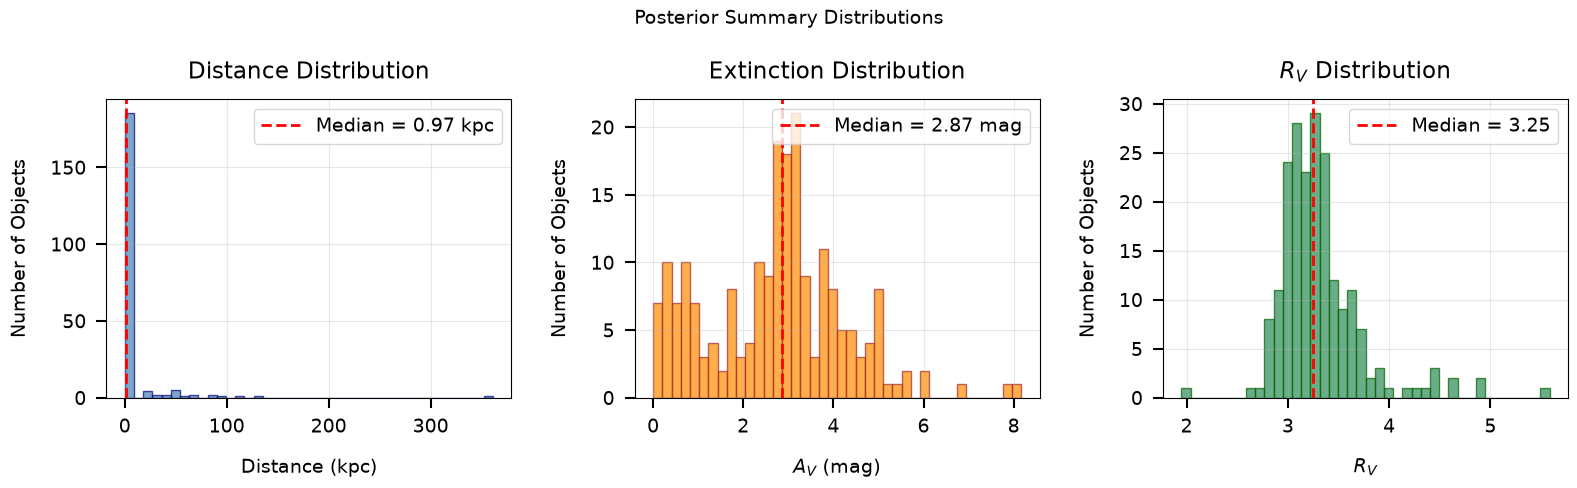

Histograms of median posterior values for all objects.


In [6]:
# Plot a distance histogram
if DATA_AVAILABLE:
    fig, axes = plt.subplots(1, 3, figsize=(16, 5))

    # Panel 1: Distance distribution
    ax = axes[0]
    valid_d = dist_med[np.isfinite(dist_med)]
    ax.hist(valid_d, bins=40, alpha=0.7, color="steelblue", edgecolor="navy")
    ax.axvline(
        np.median(valid_d), color="red", ls="--", lw=2,
        label=f"Median = {np.median(valid_d):.2f} kpc"
    )
    ax.set_xlabel("Distance (kpc)")
    ax.set_ylabel("Number of Objects")
    ax.set_title("Distance Distribution")
    ax.legend()
    ax.grid(True, alpha=0.3)

    # Panel 2: A_V distribution
    ax = axes[1]
    valid_av = av_med[np.isfinite(av_med)]
    ax.hist(valid_av, bins=40, alpha=0.7, color="darkorange", edgecolor="brown")
    ax.axvline(
        np.median(valid_av), color="red", ls="--", lw=2,
        label=f"Median = {np.median(valid_av):.2f} mag"
    )
    ax.set_xlabel(r"$A_V$ (mag)")
    ax.set_ylabel("Number of Objects")
    ax.set_title("Extinction Distribution")
    ax.legend()
    ax.grid(True, alpha=0.3)

    # Panel 3: R_V distribution
    ax = axes[2]
    valid_rv = rv_med[np.isfinite(rv_med)]
    ax.hist(valid_rv, bins=40, alpha=0.7, color="seagreen", edgecolor="darkgreen")
    ax.axvline(
        np.median(valid_rv), color="red", ls="--", lw=2,
        label=f"Median = {np.median(valid_rv):.2f}"
    )
    ax.set_xlabel(r"$R_V$")
    ax.set_ylabel("Number of Objects")
    ax.set_title(r"$R_V$ Distribution")
    ax.legend()
    ax.grid(True, alpha=0.3)

    plt.suptitle("Posterior Summary Distributions", fontsize=14)
    save_figure(fig, 11, "posterior_summaries")
    plt.show()

    print("Histograms of median posterior values for all objects.")
else:
    print("SKIPPED -- results file not available.")

---
## Section 4: Sampling from Posteriors

The `draw_sar` function generates Monte Carlo draws from the joint
`(s, A_V, R_V)` posterior for a single object. It uses the per-sample
ML estimates `(ml_scale, ml_av, ml_rv)` and local covariance matrices
`ml_cov_sar`, drawing from multivariate normals and rejection-sampling
to enforce physical bounds on A_V and R_V.

This is the standard way to generate posterior realizations for
downstream analysis (e.g., propagating uncertainties into derived
quantities like absolute magnitude or bolometric luminosity).

### Function signature

```python
draw_sar(scales, avs, rvs, covs_sar, ndraws=500,
         avlim=(0., 6.), rvlim=(1., 8.), rstate=None,
         max_attempts=10000)
```

Returns `(sdraws, adraws, rdraws)` each of shape `(Nsamps, ndraws)`.
Convert scale draws to distance via `d_kpc = 1/sqrt(s)`.

Note: all `Nsamps` distributions are drawn in a single batched call per
rejection pass. The accepted draws follow the same truncated Gaussian
distribution as in older brutus versions, but the underlying RNG stream
differs, so individual draws are not reproducible against older versions
even with a fixed seed. If a distribution has not accumulated `ndraws`
in-bounds samples after `max_attempts` rejection passes, the remaining
slots are padded with the mean values (with a warning).

In [7]:
from brutus.utils import draw_sar

print_section("Section 4: Sampling from Posteriors")

if not DATA_AVAILABLE:
    print("SKIPPED -- results file not available.")
else:
    # Pick one example object
    obj_idx = 0

    scales_obj = results["ml_scale"][obj_idx]
    avs_obj = results["ml_av"][obj_idx]
    rvs_obj = results["ml_rv"][obj_idx]
    covs_obj = results["ml_cov_sar"][obj_idx]

    print(f"Object {obj_idx}:")
    print(f"  ml_scale shape : {scales_obj.shape}")
    print(f"  ml_av shape    : {avs_obj.shape}")
    print(f"  ml_rv shape    : {rvs_obj.shape}")
    print(f"  ml_cov_sar shape: {covs_obj.shape}")

    # Draw 500 (s, A_V, R_V) realizations per sample
    ndraws = 500
    sdraws, adraws, rdraws = draw_sar(
        scales_obj, avs_obj, rvs_obj, covs_obj, ndraws=ndraws
    )

    print(f"\nDraw shapes:")
    print(f"  sdraws: {sdraws.shape}")
    print(f"  adraws: {adraws.shape}")
    print(f"  rdraws: {rdraws.shape}")

    # Flatten draws across all per-model samples
    s_flat = sdraws.ravel()
    a_flat = adraws.ravel()
    r_flat = rdraws.ravel()

    # Convert scale to distance: s = 1/d_kpc^2, so d_kpc = 1/sqrt(s)
    good = np.isfinite(s_flat) & (s_flat > 0)
    d_flat = np.full_like(s_flat, np.nan)
    d_flat[good] = 1.0 / np.sqrt(s_flat[good])  # kpc

    print(f"\nTotal draws (flattened): {len(s_flat)}")
    print(f"  Distance: median = {np.nanmedian(d_flat):.3f} kpc")
    print(f"  A_V     : median = {np.nanmedian(a_flat):.3f} mag")
    print(f"  R_V     : median = {np.nanmedian(r_flat):.3f}")

    # Compare with pre-computed samps_dist
    print(f"\nComparison with pre-computed samps_dist:")
    print(f"  samps_dist median: {np.nanmedian(results['samps_dist'][obj_idx]):.3f} kpc")
    print(f"  draw_sar median  : {np.nanmedian(d_flat):.3f} kpc")


Section 4: Sampling from Posteriors
Object 0:
  ml_scale shape : (500,)
  ml_av shape    : (500,)
  ml_rv shape    : (500,)
  ml_cov_sar shape: (500, 3, 3)



Draw shapes:
  sdraws: (500, 500)
  adraws: (500, 500)
  rdraws: (500, 500)

Total draws (flattened): 250000
  Distance: median = 0.282 kpc
  A_V     : median = 0.198 mag
  R_V     : median = 3.392

Comparison with pre-computed samps_dist:
  samps_dist median: 0.284 kpc
  draw_sar median  : 0.282 kpc


  Saved: /home/user/brutus/tutorials/plots/tutorial_11/draw_sar_scatter.png


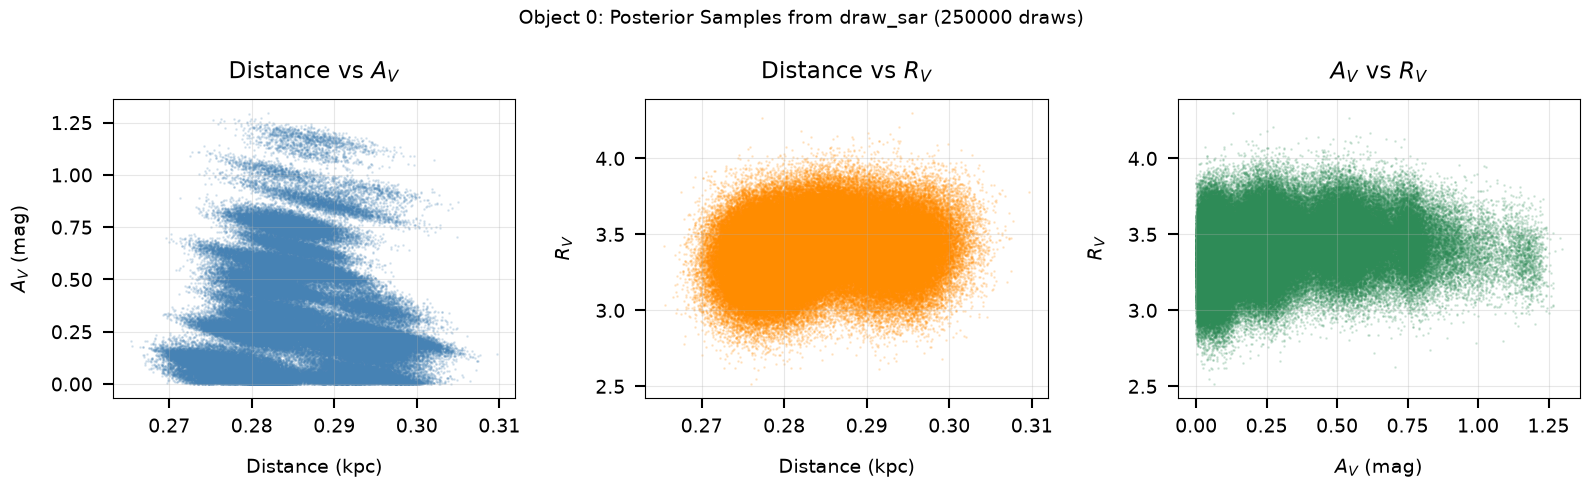

Corner-like scatter of (distance, A_V, R_V) posterior draws.
Correlations between parameters are visible in the scatter patterns.


In [8]:
# Corner-like scatter plot of the drawn posterior samples
if DATA_AVAILABLE:
    fig, axes = plt.subplots(1, 3, figsize=(16, 5))

    # Use only finite draws
    mask_good = np.isfinite(d_flat) & np.isfinite(a_flat) & np.isfinite(r_flat)
    d_plot = d_flat[mask_good]
    a_plot = a_flat[mask_good]
    r_plot = r_flat[mask_good]

    # Panel 1: Distance vs A_V
    ax = axes[0]
    ax.scatter(d_plot, a_plot, s=1, alpha=0.15, color="steelblue")
    ax.set_xlabel("Distance (kpc)")
    ax.set_ylabel(r"$A_V$ (mag)")
    ax.set_title(r"Distance vs $A_V$")
    ax.grid(True, alpha=0.3)

    # Panel 2: Distance vs R_V
    ax = axes[1]
    ax.scatter(d_plot, r_plot, s=1, alpha=0.15, color="darkorange")
    ax.set_xlabel("Distance (kpc)")
    ax.set_ylabel(r"$R_V$")
    ax.set_title(r"Distance vs $R_V$")
    ax.grid(True, alpha=0.3)

    # Panel 3: A_V vs R_V
    ax = axes[2]
    ax.scatter(a_plot, r_plot, s=1, alpha=0.15, color="seagreen")
    ax.set_xlabel(r"$A_V$ (mag)")
    ax.set_ylabel(r"$R_V$")
    ax.set_title(r"$A_V$ vs $R_V$")
    ax.grid(True, alpha=0.3)

    plt.suptitle(
        f"Object {obj_idx}: Posterior Samples from draw_sar "
        f"({len(d_plot)} draws)",
        fontsize=14,
    )
    save_figure(fig, 11, "draw_sar_scatter")
    plt.show()

    print("Corner-like scatter of (distance, A_V, R_V) posterior draws.")
    print("Correlations between parameters are visible in the scatter patterns.")
else:
    print("SKIPPED -- results file not available.")

---
## Section 5: Photometric Conversions

BruteForce works internally with **linear flux densities** (maggies),
not magnitudes. The utility functions `magnitude` and `inv_magnitude`
convert between the two representations:

$$\mathrm{flux} = 10^{-0.4 \times \mathrm{mag}}, \qquad
  \mathrm{mag} = -2.5 \log_{10}(\mathrm{flux})$$

This section demonstrates the round-trip conversion and, if the input
photometry file is available, shows a comparison between the two
representations.

In [9]:
from brutus.utils import magnitude, inv_magnitude

print_section("Section 5: Photometric Conversions")

# Demonstrate round-trip on synthetic data
np.random.seed(42)
mag_synth = np.random.uniform(14, 22, size=(5, 4))
magerr_synth = np.random.uniform(0.01, 0.1, size=(5, 4))

flux_synth, fluxerr_synth = inv_magnitude(mag_synth, magerr_synth)
mag_recov, magerr_recov = magnitude(flux_synth, fluxerr_synth)

residual = np.max(np.abs(mag_synth - mag_recov))
print(f"Round-trip mag -> flux -> mag:")
print(f"  Max |mag residual| = {residual:.2e}")
assert np.allclose(mag_synth, mag_recov, atol=1e-12), "Round-trip failed"
print("  Round-trip verified: exact to machine precision.")

# Load input photometry if available
PHOT_AVAILABLE = False
try:
    import h5py

    phot_path = find_brutus_data_file("Orion_l209.1_b-19.9.h5")
    with h5py.File(phot_path, "r") as f:
        fpix = f["photometry"]["pixel 0-0"]
        input_mag = fpix["mag"][:]
        input_magerr = fpix["err"][:]
        input_flux, input_fluxerr = inv_magnitude(input_mag, input_magerr)
        input_mask = np.isfinite(input_magerr)

    PHOT_AVAILABLE = True
    print(f"\nLoaded input photometry from {phot_path}")
    print(f"  Objects: {input_flux.shape[0]}, Filters: {input_flux.shape[1]}")
    print(f"  Example (object 0):")
    print(f"    Magnitudes: {input_mag[0]}")
    print(f"    Fluxes    : {input_flux[0]}")
except (FileNotFoundError, ImportError) as exc:
    print(f"\nInput photometry file not found (optional).")
    print(f"  ({exc})")


Section 5: Photometric Conversions
Round-trip mag -> flux -> mag:
  Max |mag residual| = 3.55e-15
  Round-trip verified: exact to machine precision.

Loaded input photometry from /home/user/brutus/tutorials/Orion_l209.1_b-19.9.h5
  Objects: 207, Filters: 8
  Example (object 0):
    Magnitudes: [16.922836 15.631483 14.976083 14.652597 14.47464  13.423    12.693
 12.522   ]
    Fluxes    : [1.7016313e-07 5.5899312e-07 1.0222727e-06 1.3770853e-06 1.6223481e-06
 4.2736583e-06 8.3714385e-06 9.7994107e-06]


---
## Section 6: Visualization

The `brutus.plotting` module provides two key functions for visualizing
BruteForce results:

- **`dist_vs_red`**: 2-D density plot of the joint distance-reddening
  posterior. We use it here for a single object; multi-object input
  (arrays of shape `(Nobj, Nsamps)`) is also accepted, in which case the
  average of the per-object 2-D PDFs is plotted.
- **`cornerplot`**: Full corner plot of all stellar parameters plus
  (A_V, R_V, distance). Requires the model grid in memory.

Below we demonstrate `dist_vs_red` (which only needs the results file)
and note the requirements for `cornerplot`.


Section 6: dist_vs_red Visualization


  Saved: /home/user/brutus/tutorials/plots/tutorial_11/dist_vs_red_demo.png


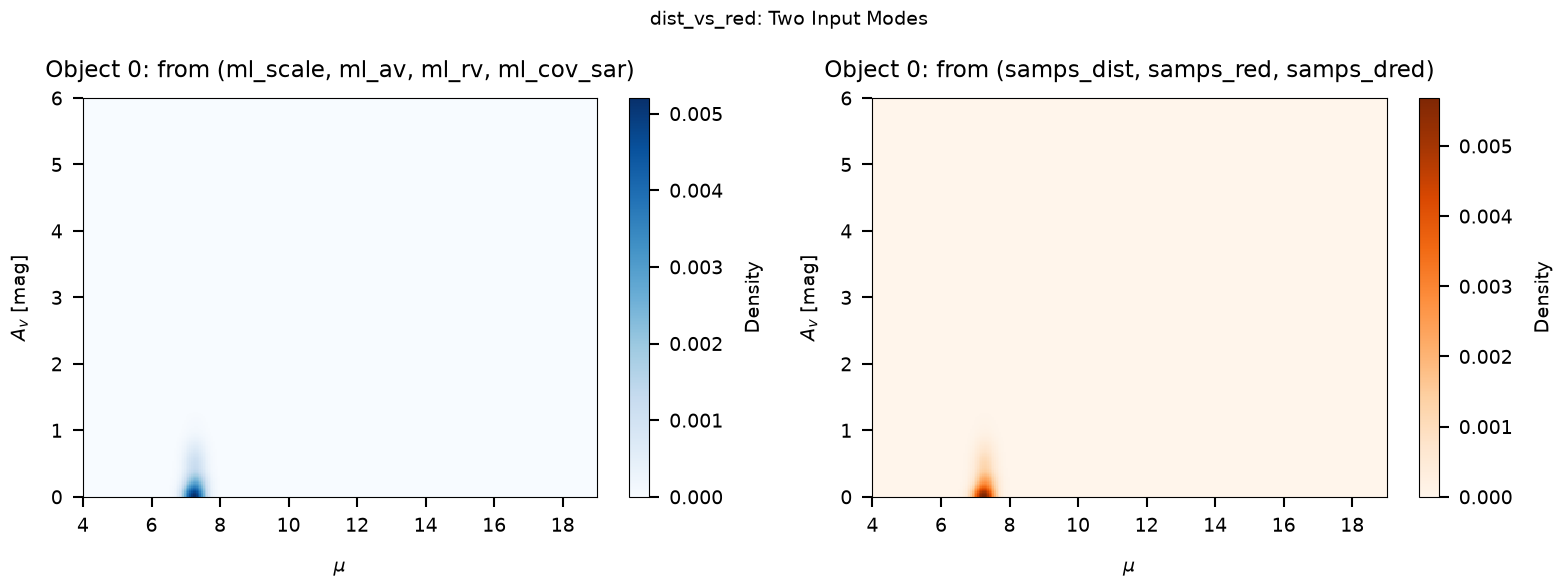

Left: 4-tuple input (ml_scale, ml_av, ml_rv, ml_cov_sar).
Right: 3-tuple input (samps_dist, samps_red, samps_dred).
Both produce the same distance-reddening posterior density.


In [10]:
from brutus.plotting import dist_vs_red

print_section("Section 6: dist_vs_red Visualization")

if not DATA_AVAILABLE:
    print("SKIPPED -- results file not available.")
else:
    obj_idx = 0

    # dist_vs_red accepts either a 4-tuple (scales, avs, rvs, covs_sar)
    # or a 3-tuple (dists, reds, dreds) of pre-computed samples.
    # Here we demonstrate both approaches.

    # Approach 1: 4-tuple with ML estimates and covariances
    # (dist_vs_red will call draw_sar internally)
    data_tuple_4 = (
        results["ml_scale"][obj_idx],
        results["ml_av"][obj_idx],
        results["ml_rv"][obj_idx],
        results["ml_cov_sar"][obj_idx],
    )

    # Approach 2: 3-tuple with pre-computed distance/reddening draws
    data_tuple_3 = (
        results["samps_dist"][obj_idx],
        results["samps_red"][obj_idx],
        results["samps_dred"][obj_idx],
    )

    # Use the Orion field centre as a default coordinate
    coord = (209.1, -19.9)

    fig, axes = plt.subplots(1, 2, figsize=(16, 6))

    # Panel 1: 4-tuple (ML + covariance -> internal draw_sar)
    plt.sca(axes[0])
    try:
        H1, xe1, ye1, img1 = dist_vs_red(
            data_tuple_4,
            coord=coord,
            dist_type="distance_modulus",
            cmap="Blues",
            smooth=0.015,
            bins=300,
        )
        axes[0].set_title(f"Object {obj_idx}: from (ml_scale, ml_av, ml_rv, ml_cov_sar)")
        plt.colorbar(img1, ax=axes[0], label="Density")
    except Exception as exc:
        axes[0].text(0.5, 0.5, f"Error: {exc}", ha="center", va="center",
                     transform=axes[0].transAxes, fontsize=9)
        axes[0].set_title("4-tuple approach (failed)")

    # Panel 2: 3-tuple (pre-computed samples)
    plt.sca(axes[1])
    try:
        H2, xe2, ye2, img2 = dist_vs_red(
            data_tuple_3,
            coord=coord,
            dist_type="distance_modulus",
            cmap="Oranges",
            smooth=0.015,
            bins=300,
        )
        axes[1].set_title(f"Object {obj_idx}: from (samps_dist, samps_red, samps_dred)")
        plt.colorbar(img2, ax=axes[1], label="Density")
    except Exception as exc:
        axes[1].text(0.5, 0.5, f"Error: {exc}", ha="center", va="center",
                     transform=axes[1].transAxes, fontsize=9)
        axes[1].set_title("3-tuple approach (failed)")

    plt.suptitle("dist_vs_red: Two Input Modes", fontsize=14)
    save_figure(fig, 11, "dist_vs_red_demo")
    plt.show()

    print("Left: 4-tuple input (ml_scale, ml_av, ml_rv, ml_cov_sar).")
    print("Right: 3-tuple input (samps_dist, samps_red, samps_dred).")
    print("Both produce the same distance-reddening posterior density.")

In [11]:
from brutus.plotting import cornerplot

print_section("Section 6b: cornerplot (reference)")

print("cornerplot requires the model grid labels array (from grid_mist_v9.h5)")
print("in addition to the results file. If you have the grid loaded, the call")
print("looks like this:")
print()
print("  fig, axes = cornerplot(")
print("      results['model_idx'][idx],")
print("      (results['ml_scale'][idx], results['ml_av'][idx],")
print("       results['ml_rv'][idx], results['ml_cov_sar'][idx]),")
print("      grid_labels,              # from load_models()")
print("      coord=(l, b),")
print("      parallax=plx,")
print("      parallax_err=plx_err,")
print("      show_titles=True,")
print("  )")
print()
print("See Tutorial 10 (Plotting Functions) for a full worked example.")


Section 6b: cornerplot (reference)
cornerplot requires the model grid labels array (from grid_mist_v9.h5)
in addition to the results file. If you have the grid loaded, the call
looks like this:

  fig, axes = cornerplot(
      results['model_idx'][idx],
      (results['ml_scale'][idx], results['ml_av'][idx],
       results['ml_rv'][idx], results['ml_cov_sar'][idx]),
      grid_labels,              # from load_models()
      coord=(l, b),
      parallax=plx,
      parallax_err=plx_err,
      show_titles=True,
  )

See Tutorial 10 (Plotting Functions) for a full worked example.


---
## Section 7: Quality Assessment

The primary diagnostic for BruteForce results is the **p-value** derived
from the chi-squared distribution. Given the best-fit `obj_chi2min` and
the degrees of freedom `dof = Nbands - 3` (three analytically
marginalized parameters: s, A_V, R_V), we compute:

$$p = 1 - F_{\chi^2}(\chi^2_{\min};\, \mathrm{dof})$$

where $F_{\chi^2}$ is the chi-squared CDF. Small p-values indicate
that the observed chi-squared is improbably large under the model,
flagging objects that are poorly fit (e.g., binaries, galaxies,
problematic photometry).

### Why not reduced chi-squared?

While the reduced chi-squared $\chi^2_\nu = \chi^2/\mathrm{dof}$ is
convenient for quick visual checks, it is **not variance-stabilizing**:
its sampling variance is $2/\mathrm{dof}$. This means a fixed threshold
like "$\chi^2_\nu > 3$" is far too lenient for objects with many bands
(where $\chi^2_\nu$ concentrates tightly around 1) and overly strict
for objects with few bands (where the distribution is broad). The
p-value approach gives a **uniform false-positive rate** regardless of
the number of bands, making it the principled choice for quality cuts.

### Log-evidence

The output also includes `obj_log_evid`, an approximate log-evidence
(marginal likelihood) computed from the grid-based Laplace
approximation. This quantity is most useful for **relative model
comparison** — e.g., comparing how well a MIST grid fits a given star
versus an alternative stellar model grid. Its absolute value is not
straightforwardly interpretable, so we do not use it as a standalone
quality metric here.

In [12]:
from scipy.stats import chi2 as chi2_dist

print_section("Section 7: Quality Assessment")

if not DATA_AVAILABLE:
    print("SKIPPED -- results file not available.")
else:
    chi2 = results["obj_chi2min"]
    Nbands = results["obj_Nbands"]

    # Degrees of freedom: 3 free parameters (s, A_V, R_V)
    n_free = 3
    dof = Nbands - n_free

    # Flag objects with insufficient bands
    insufficient = dof <= 0
    valid = ~insufficient & np.isfinite(chi2)

    print(f"Total objects          : {len(chi2)}")
    print(f"Objects with dof > 0   : {np.sum(~insufficient)}")
    print(f"Objects with dof <= 0  : {np.sum(insufficient)} (too few bands)")

    # Compute p-values from the chi-squared survival function
    pvalues = np.full(len(chi2), np.nan)
    pvalues[valid] = chi2_dist.sf(chi2[valid], dof[valid])

    if np.sum(valid) > 0:
        print(f"\nP-value summary (from chi2 CDF):")
        print(f"  Min     : {np.nanmin(pvalues[valid]):.2e}")
        print(f"  Median  : {np.nanmedian(pvalues[valid]):.3f}")
        print(f"  Max     : {np.nanmax(pvalues[valid]):.3f}")

        # Outlier flagging via p-value threshold
        p_thresh = 0.01
        outliers = valid & (pvalues < p_thresh)
        n_outliers = np.sum(outliers)
        pct_outliers = 100.0 * n_outliers / np.sum(valid)

        print(f"\nOutlier flagging (p < {p_thresh}):")
        print(f"  Flagged : {n_outliers} / {np.sum(valid)} ({pct_outliers:.1f}%)")

        good_fits = valid & (pvalues >= p_thresh)
        print(f"  Good fits: {np.sum(good_fits)} ({100.0 * np.sum(good_fits) / np.sum(valid):.1f}%)")

        # Show the flagged objects
        if n_outliers > 0:
            flagged_idx = np.where(outliers)[0]
            print(f"\n  Flagged objects:")
            print(f"  {'Obj':>5s}  {'chi2':>8s}  {'Nbands':>6s}  {'dof':>4s}  {'chi2/dof':>9s}  {'p-value':>10s}")
            for idx in flagged_idx:
                print(f"  {idx:5d}  {chi2[idx]:8.2f}  {Nbands[idx]:6d}  {dof[idx]:4d}  "
                      f"{chi2[idx]/dof[idx]:9.2f}  {pvalues[idx]:10.2e}")

        # For comparison: show why reduced chi2 thresholds are unreliable
        chi2_dof = chi2[valid] / dof[valid].astype(float)
        print(f"\nFor reference, reduced chi2 (chi2/dof) statistics:")
        print(f"  Median  : {np.median(chi2_dof):.3f}")
        print(f"  Note: The variance of chi2/dof is 2/dof, so a fixed")
        print(f"  threshold means different things at different Nbands.")

    # Log-evidence summary
    print(f"\nLog-evidence (obj_log_evid) summary:")
    lnz = results["obj_log_evid"]
    finite_lnz = lnz[np.isfinite(lnz)]
    if len(finite_lnz) > 0:
        print(f"  Min   : {np.min(finite_lnz):.2f}")
        print(f"  Median: {np.median(finite_lnz):.2f}")
        print(f"  Max   : {np.max(finite_lnz):.2f}")
        print(f"  Note: Useful for relative model comparison (e.g., MIST vs")
        print(f"  alternative grids), not as a standalone quality metric.")
    else:
        print("  (all non-finite)")


Section 7: Quality Assessment
Total objects          : 207
Objects with dof > 0   : 207
Objects with dof <= 0  : 0 (too few bands)

P-value summary (from chi2 CDF):
  Min     : 0.00e+00
  Median  : 0.001
  Max     : 0.999

Outlier flagging (p < 0.01):
  Flagged : 124 / 207 (59.9%)
  Good fits: 83 (40.1%)

  Flagged objects:
    Obj      chi2  Nbands   dof   chi2/dof     p-value
      1     50.52       9     6       8.42    3.70e-09
      2     43.95       9     6       7.33    7.55e-08
      4     44.65       9     6       7.44    5.48e-08
      5     60.21       9     6      10.04    4.07e-11
      6     51.42       9     6       8.57    2.44e-09
      7     30.75       9     6       5.13    2.82e-05
      8     25.23       9     6       4.21    3.09e-04
     12     48.33       9     6       8.06    1.01e-08
     13     99.24       9     6      16.54    3.62e-19
     14    140.20       9     6      23.37    9.12e-28
     15     86.11       9     6      14.35    1.95e-16
     16     3

  Saved: /home/user/brutus/tutorials/plots/tutorial_11/chi2_quality.png


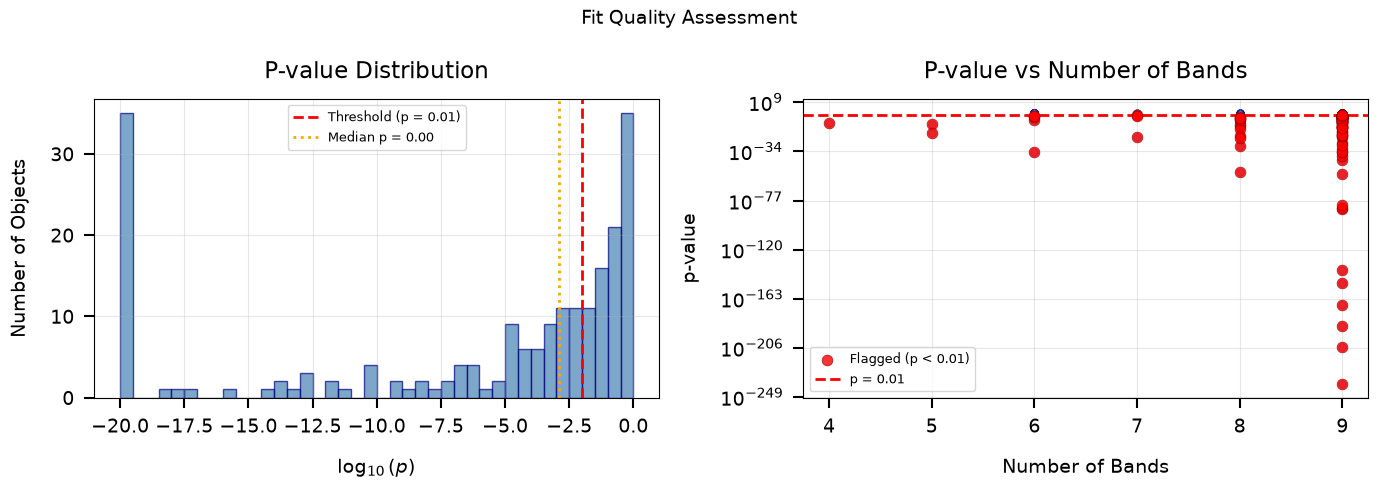

Left: histogram of log10(p-value) from the chi2 CDF.
Right: p-value vs number of bands. Unlike reduced chi2, the
p-value threshold gives a uniform false-positive rate across
all band counts.


In [13]:
# P-value quality assessment plots
if DATA_AVAILABLE and np.sum(valid) > 0:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Panel 1: P-value histogram (log scale)
    ax = axes[0]
    pvals_plot = pvalues[valid]
    # Use log10(p) for better visualization of the distribution
    log_pvals = np.log10(np.clip(pvals_plot, 1e-20, 1.0))
    ax.hist(
        log_pvals, bins=40, alpha=0.7,
        color="steelblue", edgecolor="navy"
    )
    ax.axvline(
        np.log10(p_thresh), color="red", ls="--", lw=2,
        label=f"Threshold (p = {p_thresh})"
    )
    ax.axvline(
        np.log10(np.median(pvals_plot)), color="orange", ls=":", lw=2,
        label=f"Median p = {np.median(pvals_plot):.2f}"
    )
    ax.set_xlabel(r"$\log_{10}(p)$")
    ax.set_ylabel("Number of Objects")
    ax.set_title("P-value Distribution")
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)

    # Panel 2: P-value vs number of bands
    ax = axes[1]
    ax.scatter(
        Nbands[valid], pvalues[valid],
        s=30, alpha=0.6, color="steelblue", edgecolor="navy", lw=0.5
    )
    # Highlight flagged objects
    if np.sum(outliers) > 0:
        ax.scatter(
            Nbands[outliers], pvalues[outliers],
            s=60, alpha=0.8, color="red", edgecolor="darkred", lw=0.5,
            label=f"Flagged (p < {p_thresh})", zorder=5
        )
    ax.axhline(
        p_thresh, color="red", ls="--", lw=2,
        label=f"p = {p_thresh}"
    )
    ax.set_xlabel("Number of Bands")
    ax.set_ylabel("p-value")
    ax.set_yscale("log")
    ax.set_title("P-value vs Number of Bands")
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)

    plt.suptitle("Fit Quality Assessment", fontsize=14)
    save_figure(fig, 11, "chi2_quality")
    plt.show()

    print("Left: histogram of log10(p-value) from the chi2 CDF.")
    print("Right: p-value vs number of bands. Unlike reduced chi2, the")
    print("p-value threshold gives a uniform false-positive rate across")
    print("all band counts.")
else:
    print("SKIPPED -- results file not available or no valid chi2 values.")

---
## Summary

This tutorial demonstrated how to work with BruteForce output files:

### Key Steps

1. **Loading** -- Use `load_example_results()` or open directly with `h5py`.
   Inspect top-level keys, shapes, and dtypes to understand the file layout.

2. **Output arrays** -- Per-sample arrays (`model_idx`, `ml_scale`, `ml_av`,
   `ml_rv`, `ml_cov_sar`), pre-computed draws (`samps_dist`, `samps_red`,
   `samps_dred`), and per-object summaries (`obj_chi2min`, `obj_Nbands`,
   `obj_log_evid`).

3. **Posterior summaries** -- Use `samps_dist` / `samps_red` / `samps_dred`
   for ready-to-use posterior samples, or convert `ml_scale` manually via
   `d_kpc = 1/sqrt(s)` where `s = 1/d_kpc^2`. Compute quantiles with
   `brutus.utils.quantile`.

4. **Posterior sampling** -- `draw_sar` generates Monte Carlo draws from the
   joint `(s, A_V, R_V)` posterior using the stored covariance matrices.

5. **Photometric conversions** -- `magnitude` and `inv_magnitude` convert
   between flux (maggies) and AB magnitudes.

6. **Visualization** -- `dist_vs_red` shows the 2-D distance-reddening
   posterior (accepts either 4-tuple or 3-tuple input); `cornerplot` provides
   a full multi-parameter view (requires the model grid).

7. **Quality assessment** -- Compute p-values from `obj_chi2min` via the
   chi-squared CDF (`scipy.stats.chi2.sf`). Flag objects with small p-values
   (e.g., p < 0.01) as poorly fit. Avoid using reduced chi-squared thresholds,
   which are not variance-stabilizing and behave inconsistently across
   different numbers of bands. The log-evidence `obj_log_evid` is useful
   for relative model comparison but not as a standalone quality metric.

### Related Tutorials

- **Tutorial 5** -- Fitting Individual Stars (produces the results file used here)
- **Tutorial 7** -- 3D Dust Mapping (uses distance and extinction posteriors)
- **Tutorial 9** -- Utility Functions (`quantile`, `draw_sar`, `magnitude`)
- **Tutorial 10** -- Plotting Functions (`dist_vs_red`, `cornerplot`)